In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [9]:
df = pd.read_csv("../data/churn_prediction.csv")

In [12]:
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [13]:
df.shape

(28382, 21)

In [14]:
df.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn',
       'last_transaction'],
      dtype='str')

In [15]:
df.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                                str
dependents                        float64
occupation                            str
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                      str
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

In [17]:
df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000
mean,15143.508667,2091.144105,48.208336,0.347236,796.109576,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329
std,8746.454456,272.676775,17.807163,0.997661,432.872102,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000
50%,15150.500000,2154.000000,46.000000,0.000000,834.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000


In [12]:
df.describe(include='object')

C:\Users\aiman\AppData\Local\Temp\ipykernel_18520\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,gender,occupation,last_transaction
count,27857,28302,28382
unique,2,5,361
top,Male,self_employed,NaT
freq,16548,17476,3223


In [13]:
df['churn'].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

In [14]:
df['churn'].value_counts(normalize=True) * 100

churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64

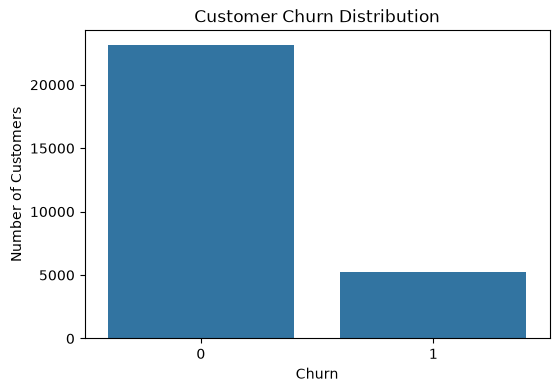

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig('../visualizations/churn_distribution.png',
            bbox_inches='tight')
plt.show()

Interpretation: The chart shows the distribution of customers according to their churn status.
The difference between churned and non-churned customers helps us understand whether the dataset is balanced or imbalanced.

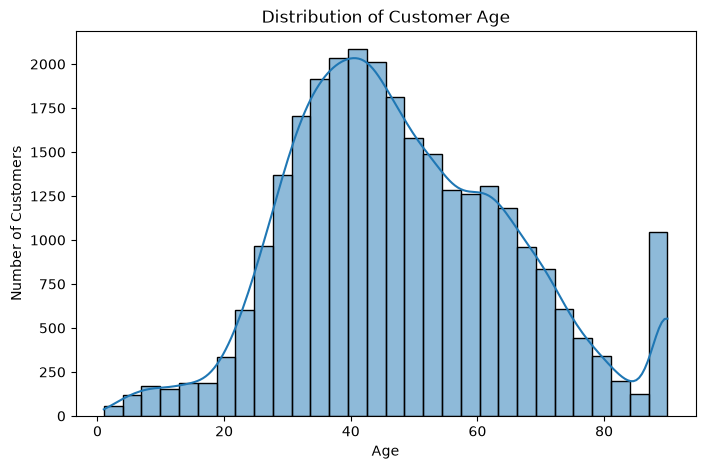

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.savefig('../visualizations/Age Distribution.png',
            bbox_inches='tight')
plt.show()

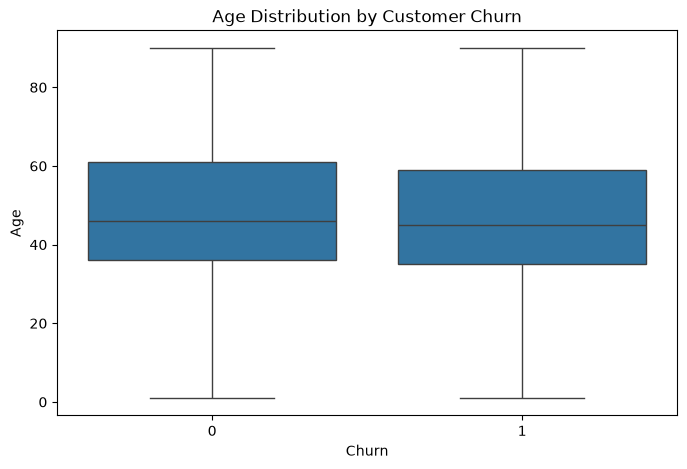

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='age')

plt.title('Age Distribution by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Age')

plt.savefig('../visualizations/Age vs Churn.png',
            bbox_inches='tight')
plt.show()

In [18]:
pd.crosstab(df['gender'], df['churn'])

churn,0,1
gender,,
Female,9324,1985
Male,13379,3169


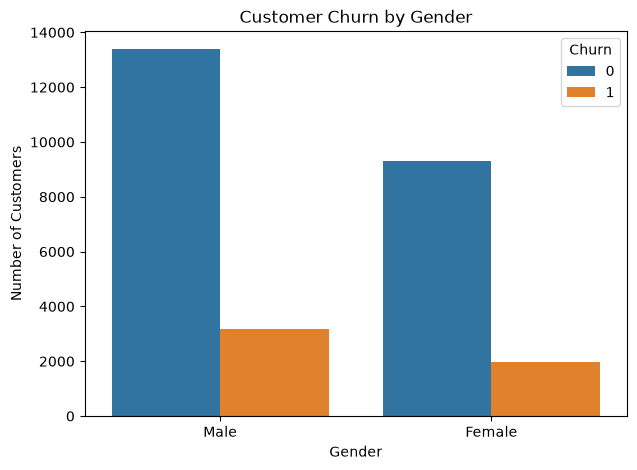

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='gender', hue='churn')

plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.savefig('../visualizations/Gender vs Churn.png',
            bbox_inches='tight')
plt.show()

In [20]:
df['occupation'].value_counts()

occupation
self_employed    17476
salaried          6704
student           2058
retired           2024
company             40
Name: count, dtype: int64

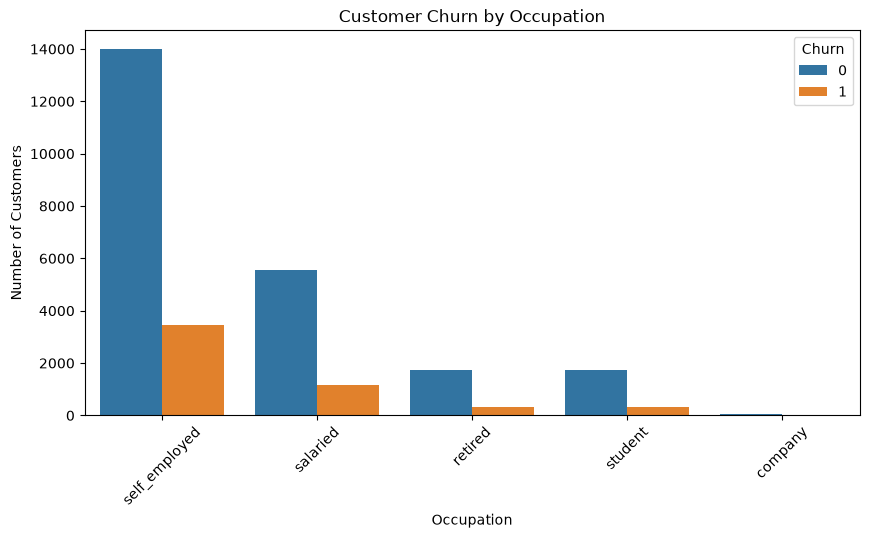

In [48]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='occupation', hue='churn')

plt.title('Customer Churn by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.legend(title='Churn')

plt.savefig('../visualizations/Occupation vs Churn.png',
            bbox_inches='tight')
plt.show()

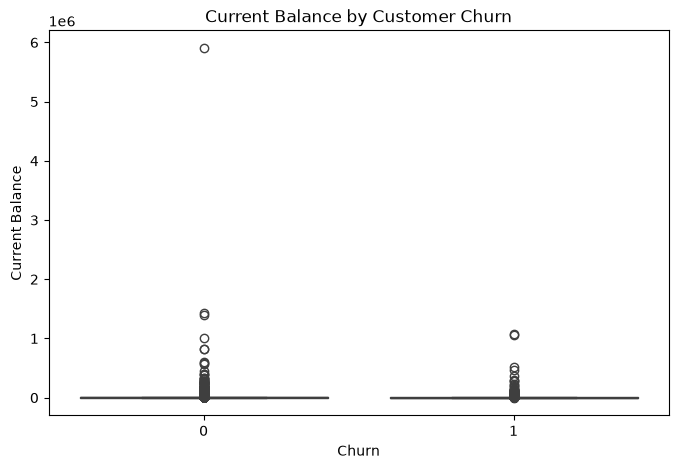

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='current_balance')

plt.title('Current Balance by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Current Balance')

plt.savefig('../visualizations/Current Balance vs Churn.png',
            bbox_inches='tight')
plt.show()

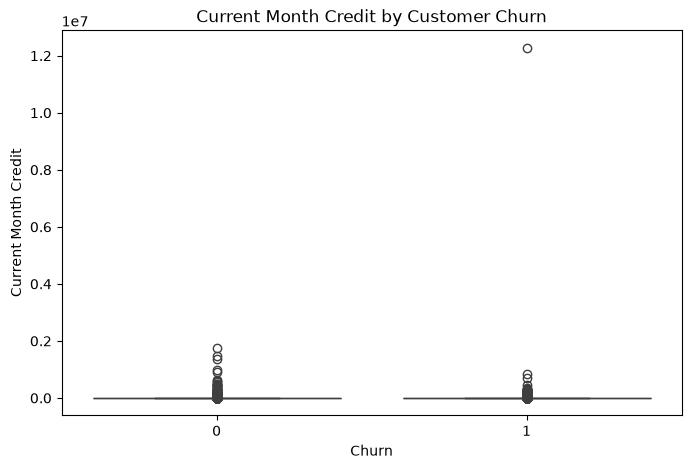

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='current_month_credit')

plt.title('Current Month Credit by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Current Month Credit')

plt.show()

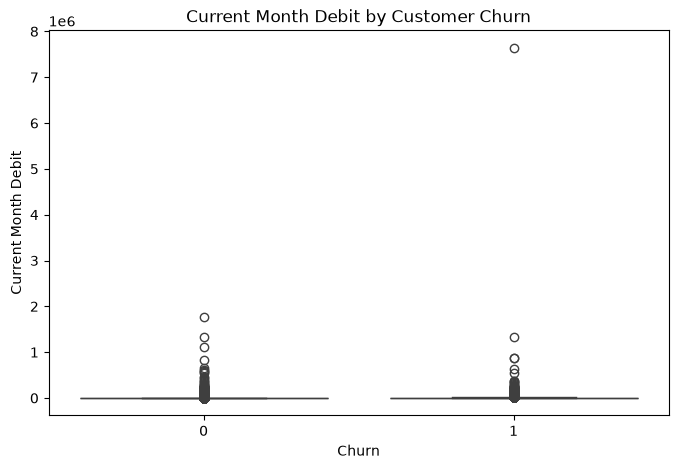

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='current_month_debit')

plt.title('Current Month Debit by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Current Month Debit')

plt.show()

In [25]:
numeric_df = df.select_dtypes(include=np.number)

In [26]:
correlation = numeric_df.corr()

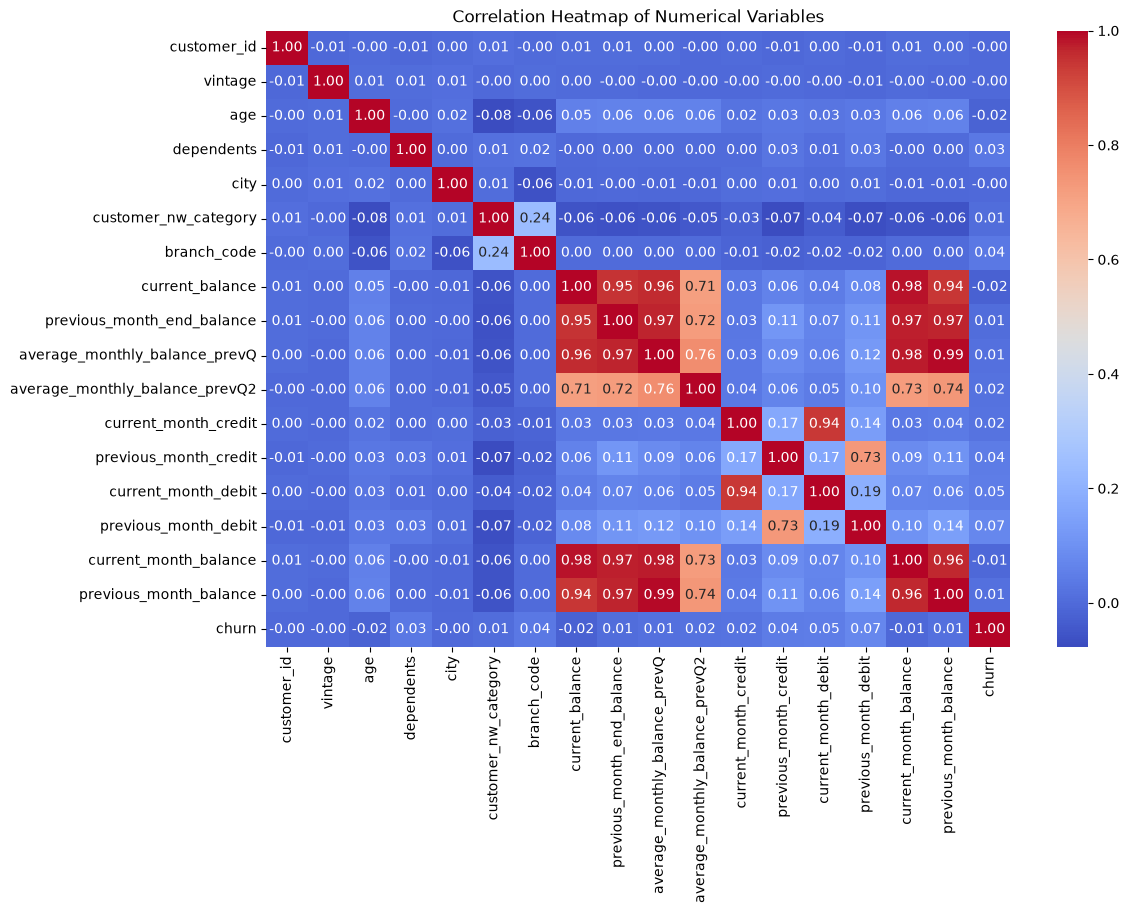

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')

plt.savefig('../visualizations/Correlation Heatmap.png',
            bbox_inches='tight')
plt.show()

In [28]:
df['customer_nw_category'].value_counts()

customer_nw_category
2    14559
3    10112
1     3711
Name: count, dtype: int64

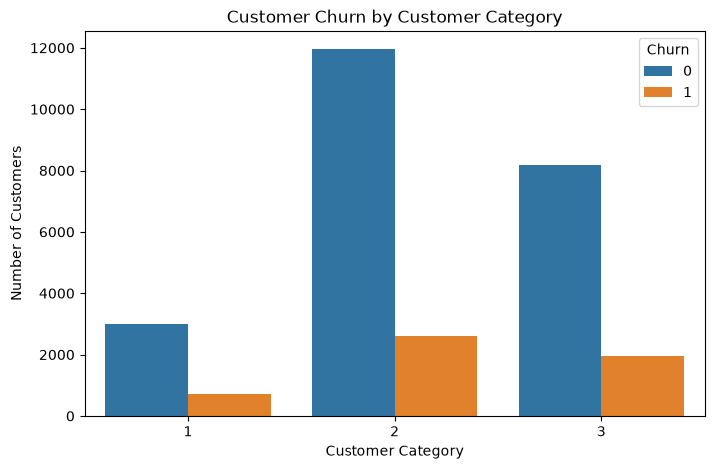

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='customer_nw_category', hue='churn')

plt.title('Customer Churn by Customer Category')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.savefig('../visualizations/churn_distribution.png',
            bbox_inches='tight')
plt.show()

In [30]:
df['dependents'].value_counts().sort_index()

dependents
0.0     21435
1.0      1395
2.0      2150
3.0       701
4.0       179
5.0        41
6.0         8
7.0         3
8.0         1
9.0         1
25.0        1
32.0        1
36.0        1
50.0        1
52.0        1
Name: count, dtype: int64

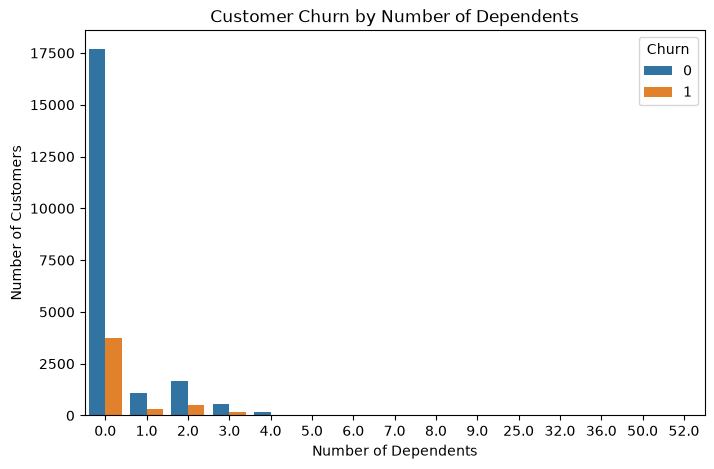

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='dependents', hue='churn')

plt.title('Customer Churn by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

In [32]:
df['vintage'].describe()

count    28382.000000
mean      2091.144105
std        272.676775
min         73.000000
25%       1958.000000
50%       2154.000000
75%       2292.000000
max       2476.000000
Name: vintage, dtype: float64

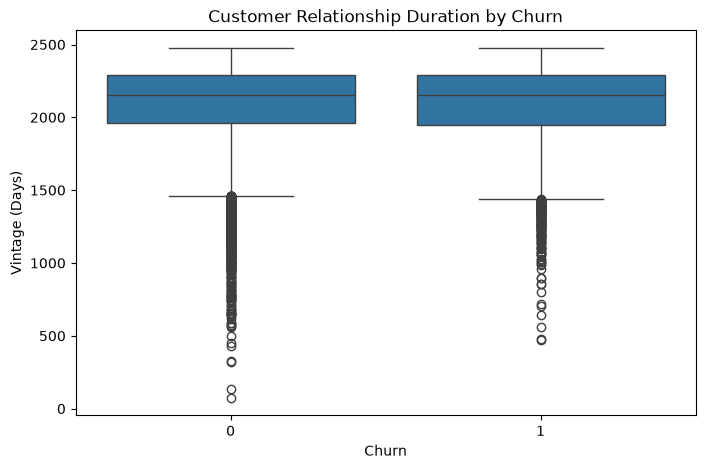

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churn', y='vintage')

plt.title('Customer Relationship Duration by Churn')
plt.xlabel('Churn')
plt.ylabel('Vintage (Days)')

plt.savefig('../visualizations/Vintage vs Churn.png',
            bbox_inches='tight')
plt.show()

In [34]:
df['last_transaction'] = pd.to_datetime(df['last_transaction'])

In [35]:
df['last_transaction'].head()

0   2019-05-21
1   2019-11-01
2          NaT
3   2019-08-06
4   2019-11-03
Name: last_transaction, dtype: datetime64[us]

In [36]:
reference_date = df['last_transaction'].max()

df['days_since_last_transaction'] = (
    reference_date - df['last_transaction']
).dt.days

In [37]:
df['days_since_last_transaction'].describe()

count    25159.000000
mean        69.997814
std         86.341098
min          0.000000
25%         11.000000
50%         30.000000
75%         95.000000
max        365.000000
Name: days_since_last_transaction, dtype: float64

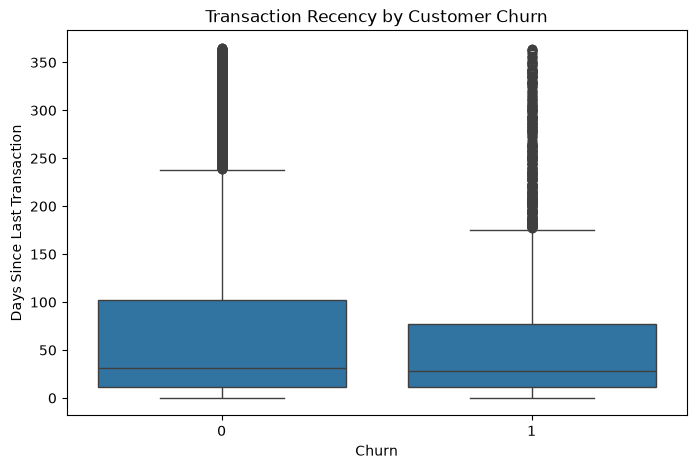

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn',
    y='days_since_last_transaction'
)

plt.title('Transaction Recency by Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Days Since Last Transaction')

plt.savefig('../visualizations/Transaction Recency vs Churn.png',
            bbox_inches='tight')
plt.show()

In [39]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

In [40]:
df['age_group'].value_counts().sort_index()

age_group
18-25    2085
26-35    5010
36-45    6805
46-55    5325
56-65    4205
65+      4952
Name: count, dtype: int64

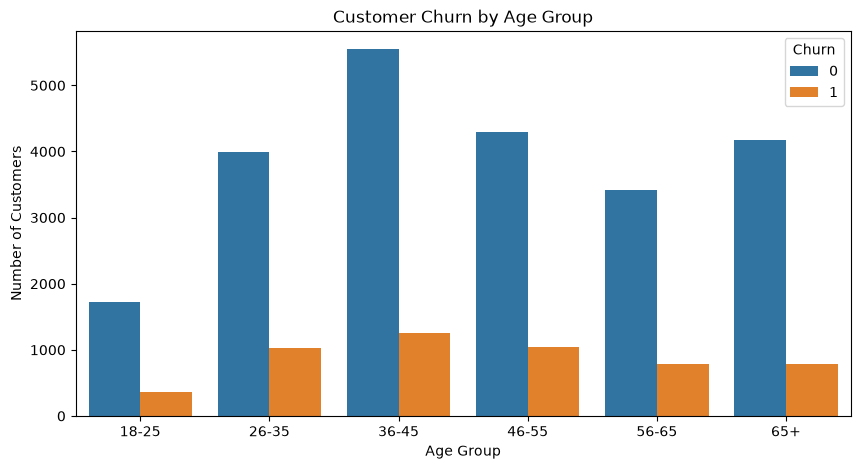

In [51]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='age_group', hue='churn')

plt.title('Customer Churn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.savefig('../visualizations/Age Group vs Churn.png',
            bbox_inches='tight')
plt.show()

In [42]:
occupation_churn = pd.crosstab(
    df['occupation'],
    df['churn'],
    normalize='index'
) * 100

occupation_churn

churn,0,1
occupation,,
company,90.000000,10.000000
retired,84.930830,15.069170
salaried,82.890811,17.109189
self_employed,80.161364,19.838636
student,84.256560,15.743440


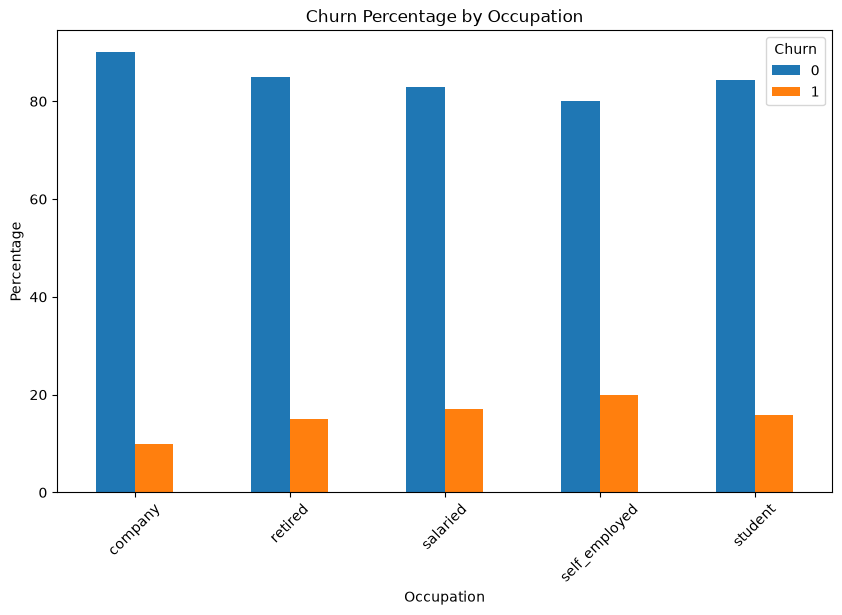

In [43]:
occupation_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Churn Percentage by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Percentage')
plt.legend(title='Churn')

plt.xticks(rotation=45)
plt.show()

In [54]:
df['churn'].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

In [55]:
df['churn'].value_counts(normalize=True) * 100


churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64

In [56]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,days_since_last_transaction
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000,25159,25159.000000
mean,15143.508667,2091.144105,48.208336,0.347236,796.109576,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329,2019-10-22 00:03:08.878731,69.997814
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000,2018-12-31 00:00:00,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000,2019-09-27 00:00:00,11.000000
50%,15150.500000,2154.000000,46.000000,0.000000,834.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000,2019-12-01 00:00:00,30.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000,2019-12-20 00:00:00,95.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000,2019-12-31 00:00:00,365.000000
std,8746.454456,272.676775,17.807163,0.997661,432.872102,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571,NaN,86.341098


In [57]:
df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                  3223
days_since_last_transaction       3223
age_group                            0
dtype: int64

In [58]:
churn_rate = df['churn'].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 18.53%


In [59]:
correlation_with_churn = df.select_dtypes(include=np.number).corr()['churn'].sort_values(
    ascending=False
)

correlation_with_churn

churn                             1.000000
previous_month_debit              0.073058
current_month_debit               0.048041
previous_month_credit             0.042179
branch_code                       0.035469
dependents                        0.033487
current_month_credit              0.020755
average_monthly_balance_prevQ2    0.018376
previous_month_balance            0.014593
average_monthly_balance_prevQ     0.011960
previous_month_end_balance        0.006886
customer_nw_category              0.006551
city                             -0.001585
customer_id                      -0.002723
vintage                          -0.004769
current_month_balance            -0.006391
age                              -0.020012
current_balance                  -0.024181
days_since_last_transaction      -0.055830
Name: churn, dtype: float64

Interpretation of Visualizations

1 Customer Churn Distribution

The customer churn distribution shows that the majority of customers have a churn value of 0, meaning they have not churned, while a considerably smaller group has a churn value of 1. Therefore, the dataset contains significantly more non-churned customers than churned customers. This indicates that the churn variable is imbalanced, which should be considered when interpreting the analysis.

From a business perspective, although churned customers represent a smaller proportion of the customer base, understanding their characteristics is important for improving customer retention.

2 Age Distribution

The age distribution shows that customers are spread across a wide range of ages. The largest concentration of customers appears to be around the middle-age range, particularly approximately 30–50 years. The number of customers decreases at the higher age ranges.

This indicates that the dataset contains customers from different age groups, making it possible to investigate whether age is associated with customer churn.

3 Age Group vs Churn

The age-group analysis shows that the 35–45 age group contains a relatively large number of customers, while other age groups also contain substantial numbers of customers. In each age group, non-churned customers are considerably more numerous than churned customers.

The pattern suggests that the difference in churn counts is partly influenced by the number of customers in each age group. Therefore, the graph does not provide strong evidence that one particular age group has a dramatically higher churn rate based only on customer counts.

4 Age vs Churn

The boxplot shows that the age distributions of churned and non-churned customers are quite similar. The median ages of the two groups are close, and both groups have a broadly similar range.

This suggests that age alone does not appear to have a strong relationship with customer churn in this dataset. Other customer characteristics and account-related factors may be more important in explaining churn.

5 Gender vs Churn

The gender analysis shows that both male and female customers contain substantially more non-churned customers than churned customers. The number of male customers is higher than the number of female customers in the dataset, and the same general churn pattern is visible for both groups.

Therefore, there is no very large difference in the overall churn pattern between the two gender categories based on this visualization. Further analysis using churn percentages rather than raw counts would provide a more accurate comparison.

6 Occupation vs Churn

The occupation analysis shows that the number of customers varies considerably across occupation categories. The largest occupation group also has the largest number of churned customers, while smaller occupation groups have fewer churned customers.

This means that raw churn counts are influenced by the size of each occupation group. Therefore, the occupation with the highest number of churned customers is not necessarily the occupation with the highest churn rate.

Occupation may still be useful for customer segmentation, but comparing churn percentages across occupations would provide a stronger conclusion.

7 Current Balance vs Churn

The current balance boxplot contains many extreme values and outliers. Most observations are concentrated near the lower part of the scale, while a small number of customers have substantially higher balances.

Because of this highly skewed distribution, the difference between churned and non-churned customers is difficult to compare clearly using the standard boxplot.

This suggests that current balance may require additional transformation or analysis, such as using a logarithmic scale, before drawing strong conclusions about its relationship with churn.

8 Transaction Recency vs Churn

The transaction-recency boxplot compares the number of days since the customer's last transaction for churned and non-churned customers. Both groups contain a wide range of values and several high-value observations.

The distributions overlap considerably, although there are differences in their spread and outliers. Therefore, transaction recency may provide some information about churn, but the visualization alone does not indicate a very strong separation between the two groups.

Further analysis using churn rates across transaction-recency groups could provide additional insight.

9 Vintage vs Churn

The vintage boxplot shows that the distributions of customer relationship duration are very similar for churned and non-churned customers. The median values of the two groups are close, and both groups have similar overall distributions.

This suggests that customer relationship duration, represented by vintage, does not appear to have a strong association with churn in this dataset.

Therefore, simply having a longer or shorter relationship with the bank does not appear to clearly distinguish churned customers from non-churned customers.

10 Correlation Heatmap

The correlation heatmap shows the relationships between the numerical variables in the dataset. Several account and transaction-related variables show relationships with one another, while many other variable pairs have relatively weak correlations.

The heatmap is useful for identifying variables that may contain related information and for understanding the overall structure of the numerical data.

Correlation, however, does not indicate causation. A strong correlation between two variables does not necessarily mean that one variable causes the other.

 Overall Interpretation

Overall, the exploratory analysis shows that customer churn is influenced by a combination of customer and account characteristics rather than being clearly explained by a single variable. Age, gender, vintage, and transaction recency show considerable overlap between churned and non-churned customers.

The analysis also highlights the importance of considering the distribution of the data. For example, raw customer counts can be affected by the size of each category, while current balance contains substantial outliers. Therefore, percentage-based comparisons and additional transformations may provide deeper insights.

The findings from this EDA can be used as a foundation for further analysis and, in future work, for developing a machine-learning model to predict customers who may be at risk of churning.


In [6]:
gender_churn = pd.crosstab(
    df['gender'],
    df['churn'],
    normalize='index'
) * 100

gender_churn

churn,0,1
gender,,
Female,82.447608,17.552392
Male,80.849650,19.150350


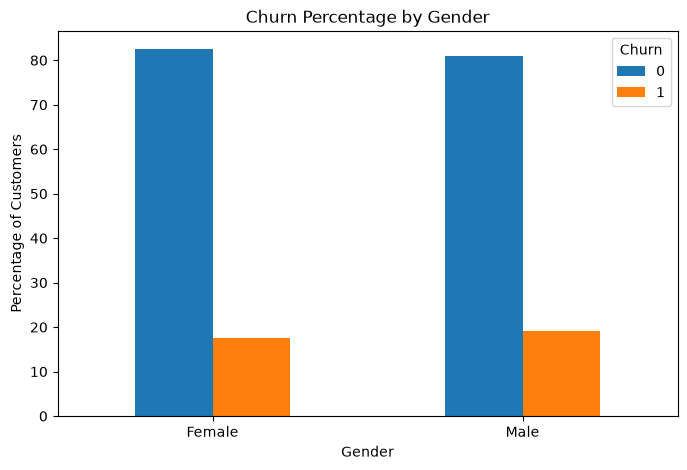

In [7]:
gender_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Percentage by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=0)

plt.savefig('../visualizations/gender_churn_percentage.png',
            bbox_inches='tight')

plt.show()

In [8]:
occupation_churn = pd.crosstab(
    df['occupation'],
    df['churn'],
    normalize='index'
) * 100

occupation_churn

churn,0,1
occupation,,
company,90.000000,10.000000
retired,84.930830,15.069170
salaried,82.890811,17.109189
self_employed,80.161364,19.838636
student,84.256560,15.743440


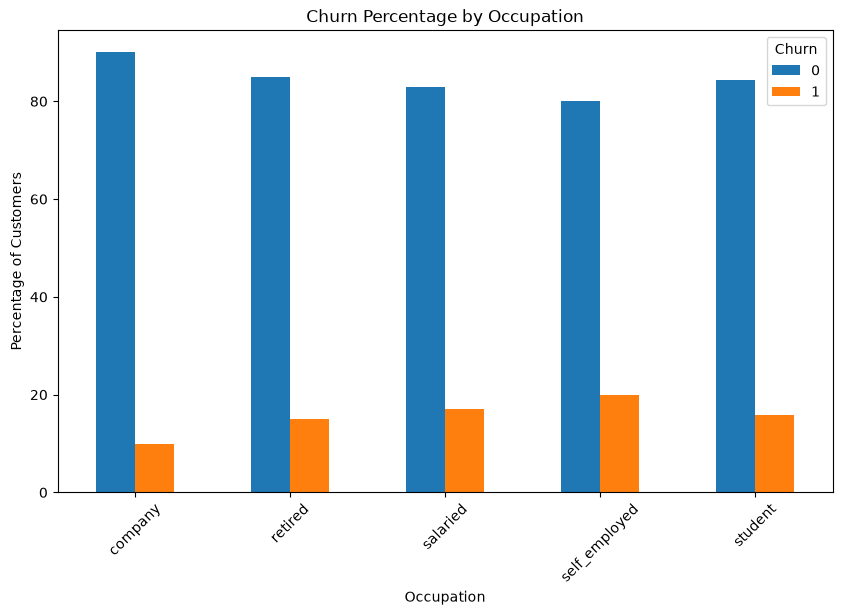

In [9]:
occupation_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Churn Percentage by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Percentage of Customers')
plt.legend(title='Churn')

plt.xticks(rotation=45)

plt.savefig('../visualizations/occupation_churn_percentage.png',
            bbox_inches='tight')

plt.show()

In [11]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

In [12]:
df[['age', 'age_group']].head()

,age,age_group
0,66,65+
1,35,26-35
2,31,26-35
3,90,65+
4,42,36-45


In [14]:
age_group_churn = pd.crosstab(
    df['age_group'],
    df['churn'],
    normalize='index'
) * 100

age_group_churn

churn,0,1
age_group,,
18-25,82.494005,17.505995
26-35,79.540918,20.459082
36-45,81.498898,18.501102
46-55,80.544601,19.455399
56-65,81.189061,18.810939
65+,84.168013,15.831987


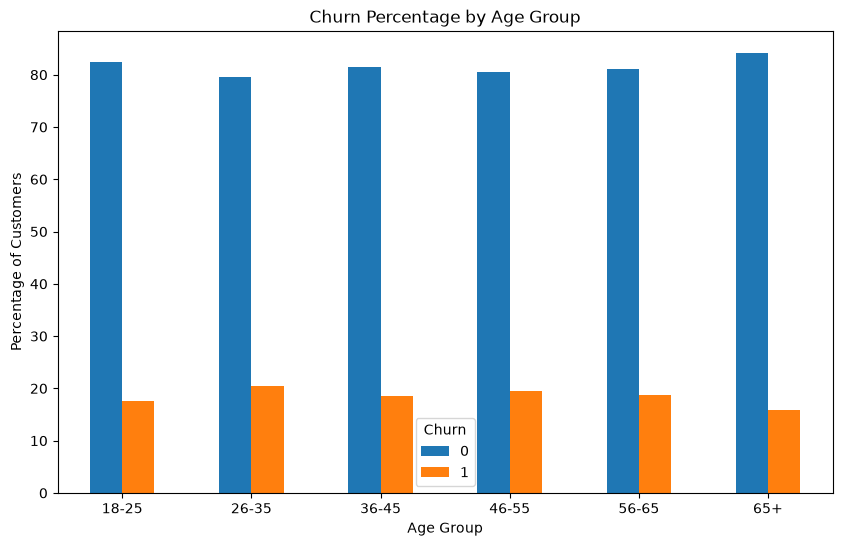

In [15]:
age_group_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Churn Percentage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=0)

plt.savefig('../visualizations/age_group_churn_percentage.png',
            bbox_inches='tight')

plt.show()

## 23. Interpretation of Percentage-Based Churn Analysis

### 23.1 Gender Churn Percentage

**Observation:** The churn percentage is relatively similar for male and female customers. However, the male group shows a slightly higher churn percentage than the female group.

**Interpretation:** The difference between the two groups is relatively small, suggesting that gender alone may not be a major factor associated with customer churn in this dataset.

**Business Insight:** The bank should not rely only on gender when identifying customers who may be at risk of churn. Other customer and account characteristics should also be considered.

### 23.2 Occupation Churn Percentage

**Observation:** The churn percentage differs across occupation categories. Self-employed customers show the highest churn percentage among the occupation groups, while customers in the company category show a comparatively lower churn percentage.

**Interpretation:** This indicates that occupation may have some association with customer churn. Differences in income patterns, financial needs, employment stability, or banking behavior could potentially contribute to these differences.

**Business Insight:** The bank could analyze the needs and transaction behavior of different occupational groups and develop more targeted customer-retention strategies.

### 23.3 Age Group Churn Percentage

**Observation:** Churn percentages are relatively consistent across the different age groups, although some variation can be observed. The 26–35 age group shows a comparatively higher churn percentage, while the 65+ group shows a comparatively lower churn percentage.

**Interpretation:** The relatively small differences between age groups suggest that age group alone does not strongly distinguish churned customers from non-churned customers.

**Business Insight:** The bank should consider age together with other variables, such as transaction behavior, account balance, occupation, and customer activity, rather than using age alone to identify potential churn.

In [21]:
gender_churn.round(2)
occupation_churn.round(2)
age_group_churn.round(2)

churn,0,1
age_group,,
18-25,82.49,17.51
26-35,79.54,20.46
36-45,81.50,18.50
46-55,80.54,19.46
56-65,81.19,18.81
65+,84.17,15.83


In [22]:
print("Overall Churn Rate:")
print(f"{df['churn'].mean() * 100:.2f}%")

Overall Churn Rate:
18.53%


In [23]:
print("Churn Rate by Gender:")
print(gender_churn[1].sort_values(ascending=False))

Churn Rate by Gender:
gender
Male      19.150350
Female    17.552392
Name: 1, dtype: float64


In [24]:
print("Churn Rate by Occupation:")
print(occupation_churn[1].sort_values(ascending=False))

Churn Rate by Occupation:
occupation
self_employed    19.838636
salaried         17.109189
student          15.743440
retired          15.069170
company          10.000000
Name: 1, dtype: float64


In [25]:
print("Churn Rate by Age Group:")
print(age_group_churn[1].sort_values(ascending=False))

Churn Rate by Age Group:
age_group
26-35    20.459082
46-55    19.455399
56-65    18.810939
36-45    18.501102
18-25    17.505995
65+      15.831987
Name: 1, dtype: float64


## 24. Key Findings

The exploratory data analysis provided several important insights into customer churn:

1. **Overall Churn Rate:** The overall churn rate in the dataset is approximately 18.53%. This means that around one-fifth of the customers have churned, while the majority of customers have remained active.

2. **Gender and Churn:** The churn rate is slightly higher among male customers (approximately 19.15%) compared with female customers (approximately 17.55%). However, the difference is relatively small, suggesting that gender alone may not be a strong indicator of customer churn.

3. **Occupation and Churn:** Churn rates vary across occupation categories. Self-employed customers have the highest churn rate at approximately 19.84%, while retired and company-related customers have comparatively lower churn rates. This suggests that occupation may have some association with customer churn.

4. **Age Group and Churn:** The 26–35 age group has the highest churn rate at approximately 20.46%, followed by the 46–55 age group at approximately 19.46%. The 65+ age group has the lowest churn rate at approximately 15.83%. This indicates that churn varies across age groups, although the differences are not extremely large.

5. **Age and Churn:** The age boxplot shows considerable overlap between churned and non-churned customers. Therefore, age alone does not appear to strongly distinguish customers who churn from those who remain.

6. **Customer Relationship Duration:** The Vintage vs Churn analysis shows similar distributions for churned and non-churned customers. This suggests that the length of the customer's relationship with the bank does not show a strong association with churn.

7. **Transaction Recency:** The transaction recency analysis shows considerable overlap between churned and non-churned customers, although differences in distribution and outliers can be observed. Transaction activity may therefore provide some useful information about churn.

8. **Current Balance:** The current balance variable contains several extreme values and outliers. This indicates that customer balances are highly unevenly distributed and may require additional transformation for deeper analysis.

### Overall Finding

Overall, the analysis suggests that customer churn cannot be explained by a single variable. Occupation and age group show some differences in churn rates, while gender, age, vintage, and transaction recency show more overlapping patterns. A combination of customer demographics, account characteristics, and transaction behavior would therefore be more useful for understanding customer churn.

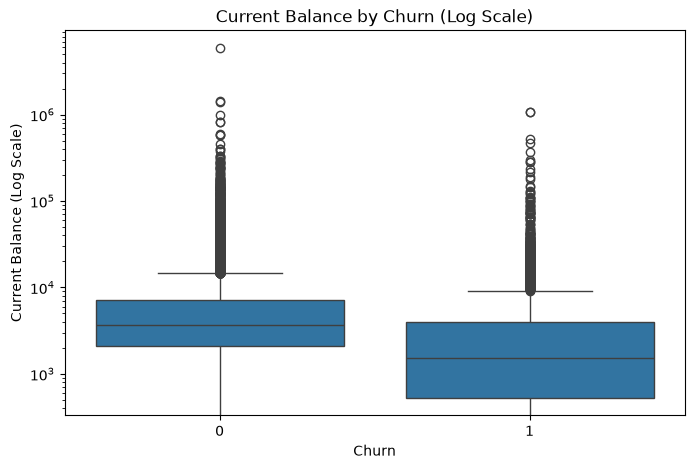

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='churn', y='current_balance')

plt.yscale('log')

plt.title('Current Balance by Churn (Log Scale)')
plt.xlabel('Churn')
plt.ylabel('Current Balance (Log Scale)')

plt.savefig(
    '../visualizations/current_balance_vs_churn_log.png',
    bbox_inches='tight'
)

plt.show()

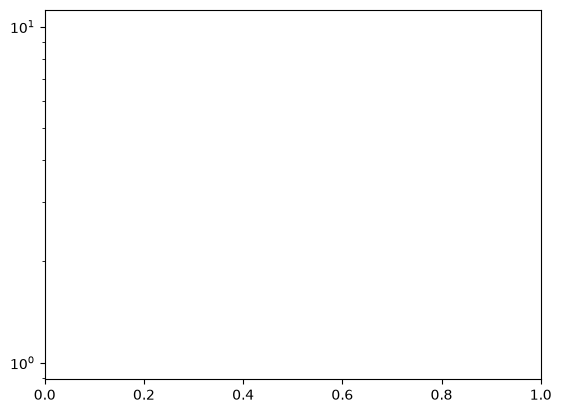

In [27]:
plt.yscale('log')

In [28]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 28382
Number of columns: 22

Column names:
['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation', 'city', 'customer_nw_category', 'branch_code', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance', 'churn', 'last_transaction', 'age_group']


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   customer_id                     28382 non-null  int64   
 1   vintage                         28382 non-null  int64   
 2   age                             28382 non-null  int64   
 3   gender                          27857 non-null  str     
 4   dependents                      25919 non-null  float64 
 5   occupation                      28302 non-null  str     
 6   city                            27579 non-null  float64 
 7   customer_nw_category            28382 non-null  int64   
 8   branch_code                     28382 non-null  int64   
 9   current_balance                 28382 non-null  float64 
 10  previous_month_end_balance      28382 non-null  float64 
 11  average_monthly_balance_prevQ   28382 non-null  float64 
 12  average_monthly_balance_prevQ

In [30]:
df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
age_group                            0
dtype: int64

## 3. Dataset Description

The dataset used for this project contains information about bank customers and their account and transaction characteristics. It consists of 28,382 customer records and 22 columns.

The dataset includes demographic information such as age, gender, dependents, occupation, and city. It also contains banking-related variables including current balance, previous month balances, monthly credits and debits, customer net worth category, branch code, and customer relationship duration.

The target variable for this analysis is `churn`, which indicates whether a customer has churned. A value of 0 represents a customer who did not churn, while a value of 1 represents a customer who churned.

The `last_transaction` column records the customer's most recent transaction date. During the analysis, this variable was converted into a date format and used to calculate transaction recency.

An additional variable called `age_group` was created during the EDA process by grouping customers into different age ranges. This transformation helped compare churn patterns across different age groups.

### Main Variables

- `customer_id` – Unique identifier for each customer.
- `vintage` – Duration of the customer's relationship with the bank, measured in days.
- `age` – Age of the customer.
- `gender` – Gender category of the customer.
- `dependents` – Number of dependents.
- `occupation` – Customer's occupation category.
- `city` – City associated with the customer.
- `customer_nw_category` – Customer net worth category.
- `branch_code` – Bank branch code.
- `current_balance` – Customer's current account balance.
- `previous_month_end_balance` – Balance at the end of the previous month.
- `average_monthly_balance_prevQ` – Average monthly balance in the previous quarter.
- `average_monthly_balance_prevQ2` – Average monthly balance in the previous quarter period.
- `current_month_credit` – Credit amount during the current month.
- `previous_month_credit` – Credit amount during the previous month.
- `current_month_debit` – Debit amount during the current month.
- `previous_month_debit` – Debit amount during the previous month.
- `current_month_balance` – Current month's balance.
- `previous_month_balance` – Previous month's balance.
- `churn` – Target variable indicating whether the customer churned.
- `last_transaction` – Date of the customer's last transaction.
- `age_group` – Age category created during the analysis.

## 4. Data Understanding

The dataset contains 28,382 customer records and 22 variables. The variables include numerical, categorical, and date-related information.

The dataset was examined using Pandas to understand its structure, data types, missing values, and statistical characteristics.

The main focus of the analysis was the `churn` variable, which was used to compare customer characteristics between churned and non-churned customers.

The dataset contains demographic variables such as age, gender, occupation, and dependents, along with financial and transaction-related variables such as current balance, credits, debits, and previous balances.

Initial exploratory analysis was performed using descriptive statistics and visualizations to identify distributions, patterns, differences between groups, and potential outliers.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   customer_id                     28382 non-null  int64   
 1   vintage                         28382 non-null  int64   
 2   age                             28382 non-null  int64   
 3   gender                          27857 non-null  str     
 4   dependents                      25919 non-null  float64 
 5   occupation                      28302 non-null  str     
 6   city                            27579 non-null  float64 
 7   customer_nw_category            28382 non-null  int64   
 8   branch_code                     28382 non-null  int64   
 9   current_balance                 28382 non-null  float64 
 10  previous_month_end_balance      28382 non-null  float64 
 11  average_monthly_balance_prevQ   28382 non-null  float64 
 12  average_monthly_balance_prevQ

In [33]:
df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
age_group                            0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000
mean,15143.508667,2091.144105,48.208336,0.347236,796.109576,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329
std,8746.454456,272.676775,17.807163,0.997661,432.872102,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000
50%,15150.500000,2154.000000,46.000000,0.000000,834.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000


## 5. Data Quality Analysis

The dataset was examined to identify missing values and understand the data types of each variable.

The dataset contains 28,382 records and 22 columns. Most variables contain complete information; however, missing values were identified in four columns: `gender`, `dependents`, `occupation`, and `city`.

The `dependents` column contains the largest number of missing values, with 2,463 missing records, representing approximately 8.68% of the dataset. The `city` column contains 803 missing values (approximately 2.83%), while `gender` contains 525 missing values (approximately 1.85%). The `occupation` column has only 80 missing values (approximately 0.28%).

The target variable `churn` contains no missing values, which means all customer records can be used for churn analysis.

The `last_transaction` column was initially stored as a string and was converted into a date format during the analysis so that transaction recency could be calculated.

An `age_group` variable was also created from the `age` column to support age-based customer segmentation.

In [19]:
df[df.isnull().any(axis=1)].head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
25,28,2271,76,Male,NaN,self_employed,1533.0,3,881,14289.26,...,14289.26,14443.43,0.64,0.64,0.64,0.64,14289.26,14289.26,0,NaT
33,36,2235,90,NaN,0.0,self_employed,834.0,3,8,1210.46,...,4672.78,6000.44,0.20,0.20,0.20,14.49,6461.22,2087.69,0,2019-10-15
41,44,2115,90,NaN,NaN,self_employed,NaN,3,2939,7870.87,...,7265.10,4324.97,0.23,0.23,0.23,0.23,7870.87,7870.87,0,2019-10-31


In [20]:
df_clean = df.copy()

In [21]:
df_clean['gender'] = df_clean['gender'].fillna('Unknown')

df_clean['occupation'] = df_clean['occupation'].fillna('Unknown')

df_clean['city'] = df_clean['city'].fillna('Unknown')

In [39]:
df_clean['dependents'].median()

np.float64(0.0)

In [40]:
df_clean['dependents'] = df_clean['dependents'].fillna(
    df_clean['dependents'].median()
)

In [41]:
df_clean.isnull().sum()

customer_id                       0
vintage                           0
age                               0
gender                            0
dependents                        0
occupation                        0
city                              0
customer_nw_category              0
branch_code                       0
current_balance                   0
previous_month_end_balance        0
average_monthly_balance_prevQ     0
average_monthly_balance_prevQ2    0
current_month_credit              0
previous_month_credit             0
current_month_debit               0
previous_month_debit              0
current_month_balance             0
previous_month_balance            0
churn                             0
last_transaction                  0
age_group                         0
dtype: int64

In [42]:
print("Missing values after treatment:")
print(df_clean.isnull().sum())

Missing values after treatment:
customer_id                       0
vintage                           0
age                               0
gender                            0
dependents                        0
occupation                        0
city                              0
customer_nw_category              0
branch_code                       0
current_balance                   0
previous_month_end_balance        0
average_monthly_balance_prevQ     0
average_monthly_balance_prevQ2    0
current_month_credit              0
previous_month_credit             0
current_month_debit               0
previous_month_debit              0
current_month_balance             0
previous_month_balance            0
churn                             0
last_transaction                  0
age_group                         0
dtype: int64


In [43]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


## 5.1 Missing Value Treatment

Missing values were identified in the `gender`, `dependents`, `occupation`, and `city` columns.

For categorical variables such as `gender`, `occupation`, and `city`, missing values were replaced with the category `Unknown`. This approach avoids making assumptions about the missing information.

The `dependents` variable is numerical and represents the number of dependents. Missing values in this column were replaced using the median value because the median is less affected by extreme values than the mean.

The last_transaction column contained 3,223 missing values. These missing dates were not replaced with artificial dates because doing so could create misleading transaction history. Therefore, these records were retained as missing and excluded automatically from calculations that require a valid transaction date

A new variable named transaction_recency was created by calculating the number of days between the latest available transaction date and each customer's last transaction date. The variable had 3,223 missing values because the corresponding last_transaction values were missing. For customers with available transaction dates, the average transaction recency was approximately 70 days, while the median was 30 days.


In [22]:
df_clean['last_transaction'].dtype

<StringDtype(storage='python', na_value=nan)>

In [23]:
df_clean['last_transaction'] = pd.to_datetime(
    df_clean['last_transaction'],
    errors='coerce'
)

In [ ]:
reference_date = df_clean['last_transaction'].max()

df_clean['transaction_recency'] = (
    reference_date - df_clean['last_transaction']
).dt.days

In [ ]:
df_clean[['last_transaction', 'transaction_recency']].head()

,last_transaction,transaction_recency
0,2019-05-21,224.0
1,2019-11-01,60.0
2,NaT,NaN
3,2019-08-06,147.0
4,2019-11-03,58.0


In [ ]:
df_clean['transaction_recency'].describe()

count    25159.000000
mean        69.997814
std         86.341098
min          0.000000
25%         11.000000
50%         30.000000
75%         95.000000
max        365.000000
Name: transaction_recency, dtype: float64